<a href="https://colab.research.google.com/github/maheshkumar30/Intellipaat-DataScience/blob/main/LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np

# The Data
X = np.array([[2,3], [3,3], [2,4], [7,8], [8,8], [7,9]])
y = np.array([0,0,0,1,1,1]) # Labels are required

# The Model (n_components = Classes - 1)
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)

print(X_lda)

[[-9.81495458]
 [-8.08290377]
 [-8.08290377]
 [ 7.5055535 ]
 [ 9.23760431]
 [ 9.23760431]]


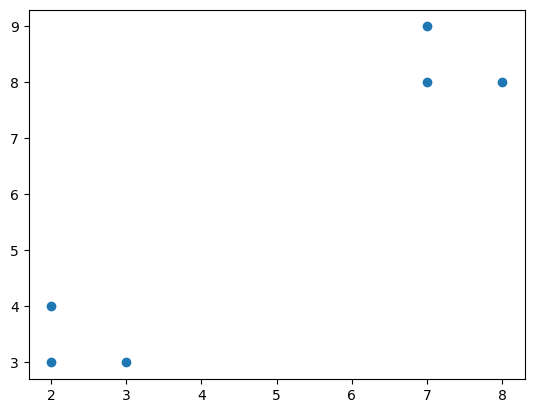

In [ ]:
plt.scatter(X[:,0],X[:,1])
plt.show()

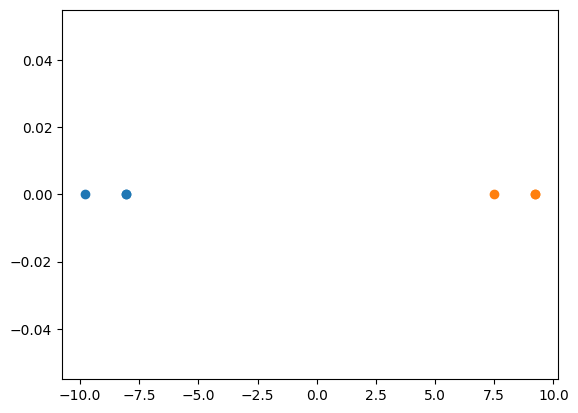

In [ ]:
plt.scatter(X_lda[y==0], np.zeros_like(X_lda[y==0]))
plt.scatter(X_lda[y==1], np.zeros_like(X_lda[y==1]))
plt.show()

###**LDA CSGO**

Dataset Link: https://drive.google.com/file/d/1y4WjD4Y2Sblbf7xSlI19WBZBaYeWIrhT/view?usp=sharing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/csgo (1).csv')
df.head()

,time_left,ct_score,t_score,map,bomb_planted,ct_health,t_health,ct_armor,t_armor,ct_money,...,t_grenade_flashbang,ct_grenade_smokegrenade,t_grenade_smokegrenade,ct_grenade_incendiarygrenade,t_grenade_incendiarygrenade,ct_grenade_molotovgrenade,t_grenade_molotovgrenade,ct_grenade_decoygrenade,t_grenade_decoygrenade,round_winner
0,175.00,0.0,0.0,de_dust2,False,500.0,500.0,0.0,0.0,4000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
1,156.03,0.0,0.0,de_dust2,False,500.0,500.0,400.0,300.0,600.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
2,96.03,0.0,0.0,de_dust2,False,391.0,400.0,294.0,200.0,750.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
3,76.03,0.0,0.0,de_dust2,False,391.0,400.0,294.0,200.0,750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
4,174.97,1.0,0.0,de_dust2,False,500.0,500.0,192.0,0.0,18350.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT


In [ ]:
df.shape

(122410, 97)

In [ ]:
df.columns

Index(['time_left', 'ct_score', 't_score', 'map', 'bomb_planted', 'ct_health',
       't_health', 'ct_armor', 't_armor', 'ct_money', 't_money', 'ct_helmets',
       't_helmets', 'ct_defuse_kits', 'ct_players_alive', 't_players_alive',
       'ct_weapon_ak47', 't_weapon_ak47', 'ct_weapon_aug', 't_weapon_aug',
       'ct_weapon_awp', 't_weapon_awp', 'ct_weapon_bizon', 't_weapon_bizon',
       'ct_weapon_cz75auto', 't_weapon_cz75auto', 'ct_weapon_elite',
       't_weapon_elite', 'ct_weapon_famas', 't_weapon_famas',
       'ct_weapon_g3sg1', 't_weapon_g3sg1', 'ct_weapon_galilar',
       't_weapon_galilar', 'ct_weapon_glock', 't_weapon_glock',
       'ct_weapon_m249', 't_weapon_m249', 'ct_weapon_m4a1s', 't_weapon_m4a1s',
       'ct_weapon_m4a4', 't_weapon_m4a4', 'ct_weapon_mac10', 't_weapon_mac10',
       'ct_weapon_mag7', 't_weapon_mag7', 'ct_weapon_mp5sd', 't_weapon_mp5sd',
       'ct_weapon_mp7', 't_weapon_mp7', 'ct_weapon_mp9', 't_weapon_mp9',
       'ct_weapon_negev', 't_weapon_negev',

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122410 entries, 0 to 122409
Data columns (total 97 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   time_left                     122410 non-null  float64
 1   ct_score                      122410 non-null  float64
 2   t_score                       122410 non-null  float64
 3   map                           122410 non-null  object 
 4   bomb_planted                  122410 non-null  bool   
 5   ct_health                     122410 non-null  float64
 6   t_health                      122410 non-null  float64
 7   ct_armor                      122410 non-null  float64
 8   t_armor                       122410 non-null  float64
 9   ct_money                      122410 non-null  float64
 10  t_money                       122410 non-null  float64
 11  ct_helmets                    122410 non-null  float64
 12  t_helmets                     122410 non-nul

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(4962)

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.shape

(117448, 97)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
time_left,117448.0,94.648097,53.224518,0.01,54.91,94.89,114.96,175.0
ct_score,117448.0,6.769566,4.802249,0.00,3.00,6.00,10.00,32.0
t_score,117448.0,6.828775,4.832447,0.00,3.00,6.00,11.00,33.0
ct_health,117448.0,408.522623,133.833268,0.00,336.00,500.00,500.00,500.0
t_health,117448.0,398.658828,141.393442,0.00,309.00,500.00,500.00,600.0
...,...,...,...,...,...,...,...,...
t_grenade_incendiarygrenade,117448.0,0.020383,0.145991,0.00,0.00,0.00,0.00,3.0
ct_grenade_molotovgrenade,117448.0,0.049605,0.231219,0.00,0.00,0.00,0.00,3.0
t_grenade_molotovgrenade,117448.0,1.386248,1.671632,0.00,0.00,1.00,3.00,5.0
ct_grenade_decoygrenade,117448.0,0.027689,0.169642,0.00,0.00,0.00,0.00,3.0


**Preprocessing**

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()

In [ ]:
df['bomb_planted'] = le.fit_transform(df['bomb_planted'])
df['map'] = le.fit_transform(df['map'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117448 entries, 0 to 122409
Data columns (total 97 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   time_left                     117448 non-null  float64
 1   ct_score                      117448 non-null  float64
 2   t_score                       117448 non-null  float64
 3   map                           117448 non-null  int64  
 4   bomb_planted                  117448 non-null  int64  
 5   ct_health                     117448 non-null  float64
 6   t_health                      117448 non-null  float64
 7   ct_armor                      117448 non-null  float64
 8   t_armor                       117448 non-null  float64
 9   ct_money                      117448 non-null  float64
 10  t_money                       117448 non-null  float64
 11  ct_helmets                    117448 non-null  float64
 12  t_helmets                     117448 non-null  fl

In [ ]:
df['round_winner'].value_counts(normalize=True)

,proportion
round_winner,
T,0.510362
CT,0.489638


In [ ]:
x = df.iloc[:,:-1]
y = df['round_winner']

In [ ]:
x.shape

(117448, 96)

In [ ]:
y.shape

(117448,)

**Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [ ]:
x_train.shape,x_test.shape

((93958, 96), (23490, 96))

**Let's Build the model withoud using LDA**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
log_model = LogisticRegression()

In [ ]:
log_model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
log_pred = log_model.predict(x_test)

**Model Evaluation**

In [ ]:
from sklearn.metrics import *

In [ ]:
accuracy_score(y_test,log_pred)

0.7443593018305662

**Now, Let's Build Model with LDA**

Let's process lda for feature selection but not extraction as we are having only two classes in the target variable
* LDA Tries to reduce dimension by picking columns that are most important for finding the difference between the groups

**We will standardize the data**
* Because LDA is sensitive to feature scales

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sc = StandardScaler()

In [ ]:
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [ ]:
new = pd.DataFrame(x_train)
new

,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
0,0.021909,0.047021,0.244115,-1.304302,-0.362769,0.683379,0.617968,0.482736,-0.062006,-0.822119,...,-1.076539,-1.052230,-0.911422,-0.913082,-0.701761,-0.13892,-0.214562,-0.830441,-0.164115,-0.155788
1,-0.557933,-0.161376,-0.791509,1.282016,-0.362769,-1.525234,-0.853816,-0.121634,-0.044759,0.341332,...,0.617719,0.058006,-0.336773,0.176346,-0.701761,-0.13892,-0.214562,-0.830441,-0.164115,-0.155788
2,0.380554,0.047021,-0.170134,1.282016,-0.362769,0.683379,0.717031,0.482736,0.984313,-0.844237,...,-0.511786,1.723360,-0.336773,1.810488,-0.018924,-0.13892,-0.214562,1.565346,-0.164115,-0.155788
3,-0.555867,1.714195,1.693989,-0.787038,-0.362769,0.683379,-0.011786,1.069504,0.547389,3.552988,...,1.182471,1.168242,-0.336773,0.721060,-0.018924,-0.13892,-0.214562,0.966399,-0.164115,-0.155788
4,1.414054,1.297402,1.486864,-0.269774,-0.362769,0.683379,0.717031,-0.837490,-1.740715,1.288019,...,0.052966,-1.052230,-0.911422,-0.913082,-0.018924,-0.13892,-0.214562,-0.830441,-0.164115,-0.155788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93953,0.381869,-1.203359,-0.377259,0.247489,-0.362769,0.683379,0.717031,1.069504,1.133787,-0.733643,...,1.182471,1.723360,1.961825,1.810488,1.346748,-0.13892,-0.214562,1.565346,-0.164115,-0.155788
93954,-0.521693,-1.203359,-1.412883,-1.304302,-0.362769,-0.152312,-1.448191,1.034298,-1.740715,-0.800000,...,-0.511786,-1.052230,-0.911422,-0.913082,-0.701761,-0.13892,-0.214562,-0.830441,-0.164115,-0.155788
93955,-1.503743,0.880608,-0.170134,-0.787038,2.756574,-2.607156,-2.820913,-1.301037,-1.740715,-0.729219,...,-1.076539,-1.052230,-0.911422,-0.913082,-0.701761,-0.13892,-0.214562,-0.830441,-0.164115,-0.155788
93956,-1.244617,-0.369772,-0.791509,0.247489,2.756574,-3.032463,-2.318525,-1.277566,-1.165815,-0.702677,...,-0.511786,-0.497112,-0.911422,-0.913082,-0.701761,-0.13892,-0.214562,-0.830441,-0.164115,-0.155788


**Let's implement LDA now**

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

In [ ]:
lda = LDA() # Here we are not passing n_components beause we want feature selection (import columns from data)

In [ ]:
lda.fit(x_train,y_train)

LinearDiscriminantAnalysis()

**When you run lda.transform(x_test), the lda model transform the test data into new spce with reduced dimension**



In [ ]:
lda.transform(x_train)

array([[-0.20756067],
       [-0.22459627],
       [ 0.59780347],
       ...,
       [-0.40631736],
       [ 0.47327557],
       [ 0.05666377]])

Each features in your dataset contributes diffently to seperate the classes
* lda.coef_ -> It provides the importance of each feature for each class

In [ ]:
lda.coef_

array([[ 1.32450954e-01, -1.28879044e-02,  1.80798217e-02,
        -8.74488465e-02,  2.39884060e-01, -4.43098719e-01,
         3.27612026e-01, -6.05431498e-01,  6.33015335e-01,
        -2.14552694e-01,  1.68532336e-01,  2.93035188e-02,
         7.33365748e-02, -2.68716636e-02, -1.96820416e-01,
         3.65434345e-01, -1.93183010e-01,  6.07498388e-01,
        -2.03626114e-01,  3.76029060e-02, -3.08425645e-01,
         2.55454777e-01,  1.01162422e-14, -5.51711468e-04,
         1.05124538e-02, -6.89279741e-03, -2.86750520e-03,
         1.94754503e-02, -1.37777398e-01,  4.62222702e-02,
        -2.14565030e-15,  1.84596657e-02, -4.97404086e-02,
         1.33798212e-01,  2.07171531e-02, -1.39679188e-01,
         2.08291232e-16, -7.30906303e-16, -9.72800626e-02,
         4.80591752e-02, -4.53505704e-01,  1.04335981e-01,
        -9.27751790e-03,  1.14628755e-01, -1.59971534e-02,
         7.82742179e-03, -1.42257642e-02,  3.76839157e-02,
         6.27982602e-03, -6.33115926e-03, -1.20967801e-0

In [ ]:
# (e = 2.71)
lda_coffecients = np.exp(np.abs(lda.coef_))
lda_coffecients

array([[1.14162302, 1.01297131, 1.01824425, 1.09138643, 1.27110177,
        1.55752608, 1.3876505 , 1.83204256, 1.88328075, 1.23930742,
        1.1835665 , 1.02973709, 1.07609266, 1.02723596, 1.21752537,
        1.44113982, 1.21310478, 1.83583311, 1.22583974, 1.03831884,
        1.36128029, 1.29104863, 1.        , 1.00055186, 1.0105679 ,
        1.00691661, 1.00287162, 1.01966633, 1.14772004, 1.04730717,
        1.        , 1.0186311 , 1.05099823, 1.14316212, 1.02093324,
        1.14990484, 1.        , 1.        , 1.10216901, 1.04923274,
        1.57381987, 1.10997332, 1.00932069, 1.12145703, 1.01612579,
        1.00785814, 1.01432743, 1.03840296, 1.00629959, 1.00635124,
        1.12858857, 1.03998677, 1.        , 1.00782618, 1.01787059,
        1.01507381, 1.02556116, 1.01876817, 1.        , 1.00634069,
        1.        , 1.01024978, 1.00138927, 1.01247098, 1.22364987,
        1.74599191, 1.08728405, 1.02362632, 1.05268431, 1.09877688,
        1.01636601, 1.00128427, 1.01376886, 1.00

**We need t osort the data based on cofficient so we converted the matrix to 1D**

In [ ]:
lda_coffecients = lda_coffecients.flatten() # It is converting the data into 1D

In [ ]:
lda_coffecients

array([1.14162302, 1.01297131, 1.01824425, 1.09138643, 1.27110177,
       1.55752608, 1.3876505 , 1.83204256, 1.88328075, 1.23930742,
       1.1835665 , 1.02973709, 1.07609266, 1.02723596, 1.21752537,
       1.44113982, 1.21310478, 1.83583311, 1.22583974, 1.03831884,
       1.36128029, 1.29104863, 1.        , 1.00055186, 1.0105679 ,
       1.00691661, 1.00287162, 1.01966633, 1.14772004, 1.04730717,
       1.        , 1.0186311 , 1.05099823, 1.14316212, 1.02093324,
       1.14990484, 1.        , 1.        , 1.10216901, 1.04923274,
       1.57381987, 1.10997332, 1.00932069, 1.12145703, 1.01612579,
       1.00785814, 1.01432743, 1.03840296, 1.00629959, 1.00635124,
       1.12858857, 1.03998677, 1.        , 1.00782618, 1.01787059,
       1.01507381, 1.02556116, 1.01876817, 1.        , 1.00634069,
       1.        , 1.01024978, 1.00138927, 1.01247098, 1.22364987,
       1.74599191, 1.08728405, 1.02362632, 1.05268431, 1.09877688,
       1.01636601, 1.00128427, 1.01376886, 1.00102851, 1.03939

**Let's Plot coffiecient scores on bar graph**

In [ ]:
feature_names = x.columns

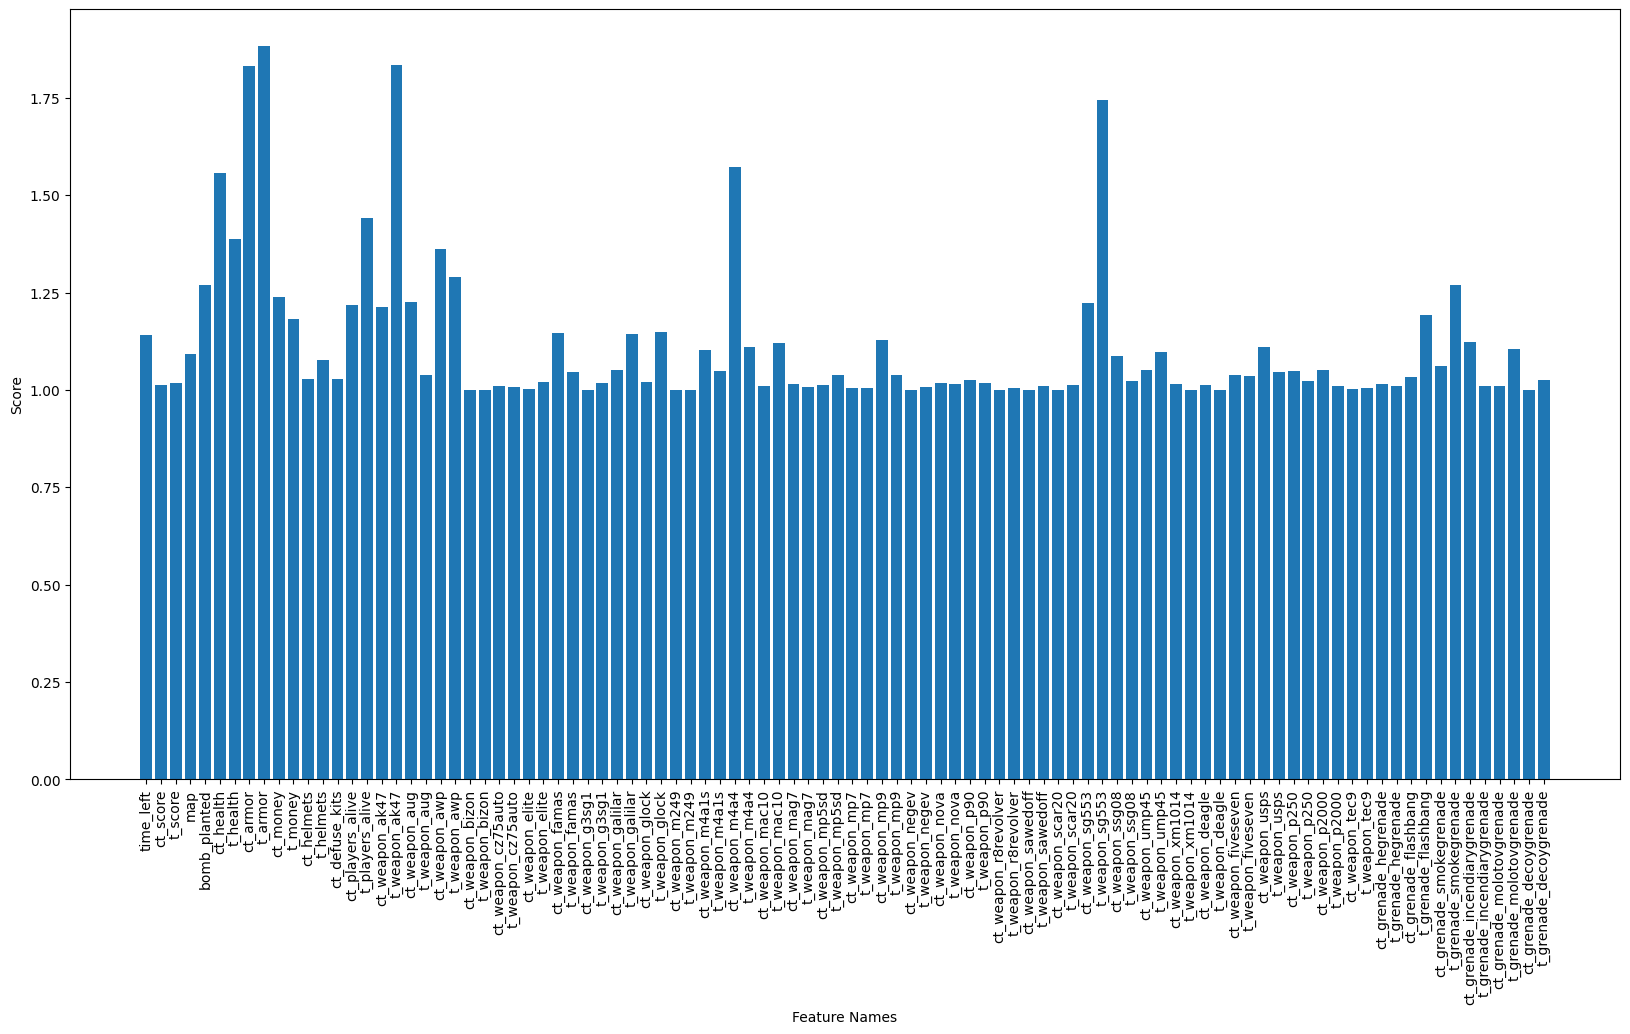

In [ ]:
plt.figure(figsize = (20,10))
plt.bar(feature_names, lda_coffecients)
plt.xticks(rotation = 90)
plt.xlabel('Feature Names')
plt.ylabel('Score')
plt.show()

In [ ]:
df_feature_score = pd.DataFrame({'FeatureNames': feature_names, "FeatureScore": lda_coffecients})
df_feature_score

,FeatureNames,FeatureScore
0,time_left,1.141623
1,ct_score,1.012971
2,t_score,1.018244
3,map,1.091386
4,bomb_planted,1.271102
...,...,...
91,t_grenade_incendiarygrenade,1.009694
92,ct_grenade_molotovgrenade,1.010343
93,t_grenade_molotovgrenade,1.104343
94,ct_grenade_decoygrenade,1.000688


In [ ]:
top_20_values = df_feature_score.nlargest(20, 'FeatureScore')
top_20_values

,FeatureNames,FeatureScore
8,t_armor,1.883281
17,t_weapon_ak47,1.835833
7,ct_armor,1.832043
65,t_weapon_sg553,1.745992
40,ct_weapon_m4a4,1.573820
5,ct_health,1.557526
15,t_players_alive,1.441140
6,t_health,1.387650
20,ct_weapon_awp,1.361280
21,t_weapon_awp,1.291049


In [ ]:
imp_cols = top_20_values.index
imp_cols

Index([8, 17, 7, 65, 40, 5, 15, 6, 20, 21, 4, 89, 9, 18, 64, 14, 16, 87, 10,
       35],
      dtype='int64')

**Now from our x_train, we will extract the above 20 important features**

In [ ]:
x_train = x_train[:, imp_cols]
x_train.shape

(93958, 20)

In [ ]:
x_test = x_test[:, imp_cols]
x_test.shape

(23490, 20)

**Let's Build the model now**

In [ ]:
log_model_lda = LogisticRegression()
log_model_lda.fit(x_train,y_train)

LogisticRegression()

In [ ]:
log_pred_lda = log_model_lda.predict(x_test)

In [ ]:
log_pred

array(['CT', 'CT', 'T', ..., 'CT', 'T', 'T'], dtype=object)

In [ ]:
accuracy_score(y_test,log_pred_lda)

0.7586206896551724

In [ ]:
print(classification_report(y_test,log_pred_lda))

              precision    recall  f1-score   support

          CT       0.75      0.76      0.75     11488
           T       0.77      0.76      0.76     12002

    accuracy                           0.76     23490
   macro avg       0.76      0.76      0.76     23490
weighted avg       0.76      0.76      0.76     23490



**Let's Try Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt_model = DecisionTreeClassifier()

In [ ]:
dt_model.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
dt_pred = dt_model.predict(x_test)

In [ ]:
accuracy_score(y_test,dt_pred)

0.7864623243933588

In [ ]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

          CT       0.79      0.77      0.78     11488
           T       0.78      0.80      0.79     12002

    accuracy                           0.79     23490
   macro avg       0.79      0.79      0.79     23490
weighted avg       0.79      0.79      0.79     23490



**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200)

In [ ]:
rf_model.fit(x_train,y_train)

RandomForestClassifier(n_estimators=200)

In [ ]:
rf_pred = rf_model.predict(x_test)

In [ ]:
accuracy_score(y_test,rf_pred)

0.8561515538527033

In [ ]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

          CT       0.85      0.86      0.85     11488
           T       0.86      0.85      0.86     12002

    accuracy                           0.86     23490
   macro avg       0.86      0.86      0.86     23490
weighted avg       0.86      0.86      0.86     23490



**For Load Digits and Load wine dataset. apply LDA**

In [ ]:
from sklearn.datasets import load_wine
wine = load_wine()
wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1